你这个视频讲的东西，其实**不是“神秘技巧”**，而是：

> 👉 Advances in Financial Machine Learning 里一个非常核心的概念
> 👉 **用“成交量/金额驱动的采样”替代时间轴**

也就是：

# 🔥 你看到的本质：Volume Clock（成交量时钟）

---

# 🧠 一、书里到底在讲什么？

在这本书第2章：

👉 核心观点：

> ❗ **时间不是市场的真实尺度，交易量才是**

---

## 📌 传统方式（时间轴）

```text
每1分钟生成一根K线
```

问题：

* 冷清时间 → 也生成数据 ❌
* 活跃时间 → 信息被压缩 ❌

👉 导致：

* 异方差（heteroskedasticity）
* 非正态分布
* 自相关严重

---

## 📌 新方式（书里的方法）

👉 用“成交量”当时间轴：

### 1️⃣ Volume Bars（成交量K线）

```text
每成交 1000 BTC 才生成一根K线
```

### 2️⃣ Dollar Bars（金额K线）

```text
每成交 1,000,000 USDT 才生成一根K线
```

---

📖 书中结论（非常关键）：

> 👉 用 volume/dollar 采样后
> 👉 数据更接近 IID + 更接近正态分布 ([studylib.net][1])

---

# ⚠️ 二、这和你看到的视频完全一致

你那张图其实在做：

| 左图        | 右图  |
| --------- | --- |
| 自定义轴（成交量） | 时间轴 |

结果：

👉 左边更接近正态 ✔
👉 右边 fat-tail ❌

---

# 🧠 三、为什么会这样？（核心机制）

这是关键理解，不然你只是“模仿”

---

## ❗ 本质：市场信息 ≠ 均匀到达

市场是这样的：

* 没人交易 → 没信息
* 大量成交 → 信息爆发

---

### 👉 时间轴的问题：

```text
时间是均匀的，但信息不是
```

导致：

* 有些bar几乎没信息
* 有些bar包含大量信息

👉 分布被“扭曲”

---

### 👉 成交量轴：

```text
每个bar包含“相似的信息量”
```

👉 结果：

* 方差更稳定（homoskedastic）
* 更接近正态
* 更接近 IID

---

# 📊 四、你可以这样理解（非常关键）

你之前的问题：

👉 “能不能让分布更正态？”

---

## ❌ 你之前的思路（错方向）

* 用 transform（log / quantile）
  👉 **数学上改造数据**

---

## ✅ 这个方法（正确方向）

* 改“采样方式”
  👉 **从源头改变数据结构**

---

👉 本质区别：

| 方法          | 本质       |
| ----------- | -------- |
| 变换          | 修饰结果     |
| volume bars | 改变数据生成机制 |

---

# 🔥 五、书里更高级的版本（视频可能没讲）

不仅仅是 volume bars，还有：

---

## 1️⃣ Tick Bars

```text
每 N 笔交易一个bar
```

---

## 2️⃣ Imbalance Bars（高级）

👉 当买卖不平衡达到阈值才采样

---

## 3️⃣ Run Bars（更高级）

👉 连续买/卖力量累积触发bar

---

📖 书里原话核心思想：

> 👉 当“信息到达”时才采样，而不是按时间 ([studylib.net][2])

---

# 🧠 六、这对你意味着什么（重点）

你现在做：

* Z-score
* 分布分析
* 均值回归

---

## ❗ 最大问题：

👉 你用的是“时间轴数据”

---

## ✔ 如果你换成 volume bars：

你会得到：

* 更稳定的分布
* 更少极端值
* 更可靠的Z-score

---

👉 直接提升：

* 特征质量
* 模型稳定性
* 策略鲁棒性

---

# ⚙️ 七、给你一个可落地实现（核心）

## 用成交量重采样

```python
def volume_bars(df, volume_threshold):
    bars = []
    cum_vol = 0
    temp = []

    for i, row in df.iterrows():
        cum_vol += row['volume']
        temp.append(row)

        if cum_vol >= volume_threshold:
            bar = {
                'open': temp[0]['price'],
                'high': max(x['price'] for x in temp),
                'low': min(x['price'] for x in temp),
                'close': temp[-1]['price'],
                'volume': cum_vol
            }
            bars.append(bar)
            cum_vol = 0
            temp = []

    return pd.DataFrame(bars)
```

---

# 🧾 八、一句话总结

👉 你视频里那个“神操作”的本质是：

> ❗ **不是让数据变正态，而是用“成交量”作为时间，让数据天然更接近正态**

---

# 🔥 最关键一句（你一定要记住）

> 👉 **市场的“时间单位”不是秒，而是成交量**

---

# 如果你要继续深入（强烈建议）

我可以帮你直接做：

👉 对比三种数据结构的策略效果：

1. 时间K线
2. Volume bars
3. Dollar bars

并且：

* 接入你现在的 Z-score策略
* 做回测对比

👉 这个会直接改变你策略的质量层级。

[1]: https://studylib.net/doc/26238834/advances-in-financial-machine-learning-1nbsped-9781119482...?utm_source=chatgpt.com "Advances in Financial Machine Learning Book Reviews"
[2]: https://studylib.net/doc/28379966/advances-in-financial-machine-learning?utm_source=chatgpt.com "Advances in Financial Machine Learning"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:


agg_df=pd.read_csv('../data/DOGEUSDT-aggTrades-2026-03.csv')
agg_df.head()

,agg_trade_id,price,quantity,first_trade_id,last_trade_id,transact_time,is_buyer_maker
0,999334769,0.09399,26536.0,3254807600,3254807614,1772323200005,True
1,999334770,0.09400,1829.0,3254807615,3254807622,1772323201300,False
2,999334771,0.09401,35364.0,3254807623,3254807633,1772323201356,False
3,999334772,0.09401,15644.0,3254807634,3254807640,1772323201536,False
4,999334773,0.09402,180167.0,3254807641,3254807672,1772323201632,False


In [3]:
def imbalance_bars(df, threshold):
    bars = []

    imbalance = 0
    open_, high_, low_ = None, -float('inf'), float('inf')

    for row in df.itertuples():
        price = row.price
        volume = row.quantity

        sign = -1 if row.is_buyer_maker else 1

        if open_ is None:
            open_ = price

        high_ = max(high_, price)
        low_ = min(low_, price)

        imbalance += sign * volume
        close_ = price

        if abs(imbalance) >= threshold:
            bars.append({
                'open': open_,
                'high': high_,
                'low': low_,
                'close': close_,
                'imbalance': imbalance
            })

            imbalance = 0
            open_, high_, low_ = None, -float('inf'), float('inf')

    return pd.DataFrame(bars)


In [3]:
def dollar_bars(df, threshold):
    bars = []

    cum_dollar = 0
    open_, high_, low_ = None, -float('inf'), float('inf')

    for row in df.itertuples():
        price = row.price
        volume = row.quantity

        dollar = price * volume

        if open_ is None:
            open_ = price

        high_ = max(high_, price)
        low_ = min(low_, price)
        cum_dollar += dollar
        close_ = price

        if cum_dollar >= threshold:
            bars.append({
                'open': open_,
                'high': high_,
                'low': low_,
                'close': close_,
                'dollar': cum_dollar
            })

            cum_dollar = 0
            open_, high_, low_ = None, -float('inf'), float('inf')

    return pd.DataFrame(bars)



In [37]:
def volume_bars(df, volume_threshold):
    bars = []

    cum_vol = 0
    open_, high_, low_ = None, -float('inf'), float('inf')
    start_time = None

    for row in df.itertuples(index=False):
        price = row.price
        volume = row.quantity
        ts = row.transact_time

        if open_ is None:
            open_ = price
            start_time = ts

        high_ = max(high_, price)
        low_ = min(low_, price)
        close_ = price

        cum_vol += volume

        while cum_vol >= volume_threshold:
            bars.append({
                'open': open_,
                'high': high_,
                'low': low_,
                'close': close_,
                'volume': volume_threshold,
                'start_time': start_time,
                'end_time': ts
            })

            cum_vol -= volume_threshold
            open_, high_, low_ = None, -float('inf'), float('inf')
            start_time = None

    return pd.DataFrame(bars)


In [ ]:
def tick_imbalance_bars(df):
    bars = []
    imbalance = 0
    open_price = None
    high_price = -float('inf')
    low_price = float('inf')

    # 书本要求：动态维护 E[T] 和 E[b]
    avg_tick_length = 10  # 初始值
    avg_b = 0.5          # 初始偏向值
    alpha = 0.9          # EWMA 系数

    for row in df.itertuples():
        price = row.price
        # 1. 正确符号：不乘成交量
        sign = -1 if row.is_buyer_maker else 1

        # 初始化K线
        if open_price is None:
            open_price = price

        high_price = max(high_price, price)
        low_price = min(low_price, price)

        # 2. 正确累加：只加 sign，不加 volume
        imbalance += sign
        close_price = price

        # 3. 书本动态阈值
        threshold = avg_tick_length * abs(avg_b)

        # 触发切 bar
        if abs(imbalance) >= threshold:
            bars.append({
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'imbalance': imbalance,
                'threshold': threshold
            })

            # 4. 关键！imbalance 不重置！
            # imbalance = 0  ❌ 不要写

            # 重新计算下一根 bar 的动态阈值（书本核心）
            current_bar_length = len(bars)  # 简化
            avg_tick_length = alpha * avg_tick_length + (1-alpha) * current_bar_length
            avg_b = alpha * avg_b + (1-alpha) * sign

            # 重置K线，不重置imbalance
            open_price = None
            high_price = -float('inf')
            low_price = float('inf')

    return pd.DataFrame(bars)

In [5]:
bars=dollar_bars(agg_df, threshold=5000000)
#把时间转换为时间戳
# bars['start_time']=pd.to_datetime(bars['start_time'], unit='ms')
# bars['end_time']=pd.to_datetime(bars['end_time'], unit='ms')
bars.head(20)



,open,high,low,close,dollar
0,0.09399,0.09422,0.09376,0.09376,5.000237e+06
1,0.09375,0.09391,0.09357,0.09358,5.024109e+06
2,0.09357,0.09392,0.09347,0.09372,5.135234e+06
3,0.09372,0.09377,0.09363,0.09377,5.023179e+06
4,0.09377,0.09390,0.09317,0.09322,5.001403e+06
5,0.09321,0.09336,0.09314,0.09331,5.007126e+06
6,0.09330,0.09379,0.09303,0.09379,5.000683e+06
7,0.09379,0.09437,0.09364,0.09437,5.009211e+06
8,0.09438,0.09464,0.09428,0.09461,5.000478e+06
9,0.09462,0.09527,0.09460,0.09512,5.034213e+06


In [6]:
bars['return'] = bars['close'].pct_change() 
bars['return_mean'] = bars['return'].rolling(window=30).mean()
bars['return_std'] = bars['return'].rolling(window=30).std()
bars['zscore_return'] = (bars['return'] - bars['return_mean']) / bars['return_std']
#log return
bars['log_return'] = np.log(1 + bars['return'])
#log return的z-score
bars.dropna(inplace=True)


μ=-0.0000, σ=0.0033
K-S test statistic: 0.0172, p-value: 0.0574
K-S检验结论: 数据服从正态分布 (p > 0.01)
Jarque-Bera test statistic: 30.6410, p-value: 0.0000
Jarque-Bera检验结论: 数据不服从正态分布 (p ≤ 0.01)


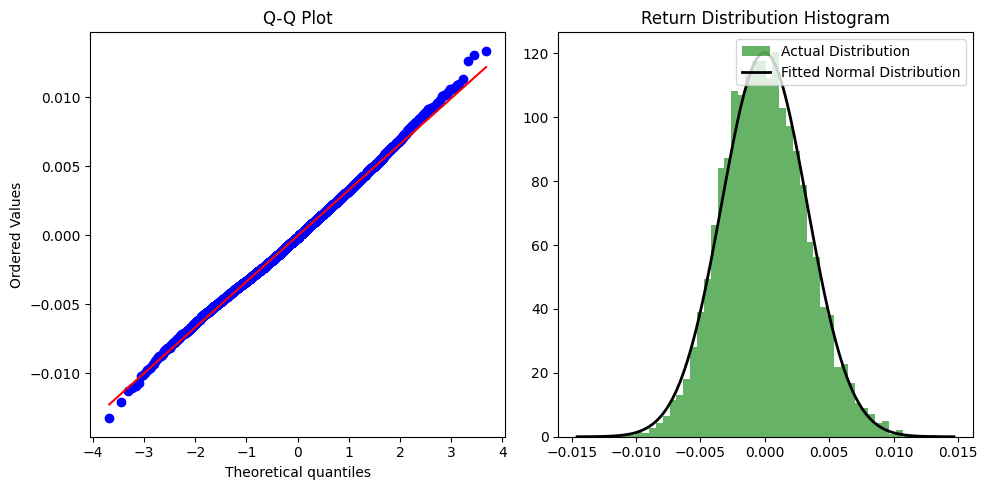

Skewness: 0.1612, Kurtosis: 0.1398
偏度判断: 分布近似对称
峰度判断: 分布峰度接近正态分布

=== 综合正态性判断 (置信度 α=0.01) ===
通过检验数: 2/3
最终结论: 数据近似符合正态分布


In [76]:
# Verify if bars["return"] follows normal distribution
import scipy.stats as stats
import matplotlib.pyplot as plt

# 设置置信度阈值为0.01（更宽松的标准）
ALPHA = 0.01

mu, sigma = stats.norm.fit(bars["return"])
print(f"μ={mu:.4f}, σ={sigma:.4f}")

# Perform K-S test
ks_stat, ks_pvalue = stats.kstest(bars["return"], 'norm', args=(mu, sigma))
print(f"K-S test statistic: {ks_stat:.4f}, p-value: {ks_pvalue:.4f}")
# 直接判断K-S检验结果
if ks_pvalue > ALPHA:
    print(f"K-S检验结论: 数据服从正态分布 (p > {ALPHA})")
else:
    print(f"K-S检验结论: 数据不服从正态分布 (p ≤ {ALPHA})")

# Perform Shapiro-Wilk test (suitable for small samples)
if len(bars["return"]) <= 5000:
    shapiro_stat, shapiro_pvalue = stats.shapiro(bars["return"])
    print(f"Shapiro-Wilk test statistic: {shapiro_stat:.4f}, p-value: {shapiro_pvalue:.4f}")
    # 直接判断Shapiro-Wilk检验结果
    if shapiro_pvalue > ALPHA:
        print(f"Shapiro-Wilk检验结论: 数据服从正态分布 (p > {ALPHA})")
    else:
        print(f"Shapiro-Wilk检验结论: 数据不服从正态分布 (p ≤ {ALPHA})")

# Perform Jarque-Bera test
jb_stat, jb_pvalue = stats.jarque_bera(bars["return"])
print(f"Jarque-Bera test statistic: {jb_stat:.4f}, p-value: {jb_pvalue:.4f}")
# 直接判断Jarque-Bera检验结果
if jb_pvalue > ALPHA:
    print(f"Jarque-Bera检验结论: 数据服从正态分布 (p > {ALPHA})")
else:
    print(f"Jarque-Bera检验结论: 数据不服从正态分布 (p ≤ {ALPHA})")

# Plot Q-Q plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
stats.probplot(bars["return"], dist="norm", plot=plt)
plt.title("Q-Q Plot")

# Plot histogram with fitted normal distribution
plt.subplot(1, 2, 2)
plt.hist(bars["return"], bins=50, density=True, alpha=0.6, color='g', label='Actual Distribution')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal Distribution')
plt.title("Return Distribution Histogram")
plt.legend()
plt.tight_layout()
plt.show()

# Calculate skewness and kurtosis
skewness = stats.skew(bars["return"])
kurtosis = stats.kurtosis(bars["return"])
print(f"Skewness: {skewness:.4f}, Kurtosis: {kurtosis:.4f}")
# 直接判断偏度和峰度
if abs(skewness) < 0.5:
    print("偏度判断: 分布近似对称")
elif skewness > 0:
    print("偏度判断: 分布右偏")
else:
    print("偏度判断: 分布左偏")

if abs(kurtosis) < 0.5:
    print("峰度判断: 分布峰度接近正态分布")
elif kurtosis > 0:
    print("峰度判断: 分布尖峰(厚尾)")
else:
    print("峰度判断: 分布低峰(薄尾)")

# 综合判断
print(f"\n=== 综合正态性判断 (置信度 α={ALPHA}) ===")
normal_tests_passed = 0
normal_tests_total = 0

if ks_pvalue > ALPHA:
    normal_tests_passed += 1
normal_tests_total += 1

if len(bars["return"]) <= 5000:
    if shapiro_pvalue > ALPHA:
        normal_tests_passed += 1
    normal_tests_total += 1

if jb_pvalue > ALPHA:
    normal_tests_passed += 1
normal_tests_total += 1

if abs(skewness) < 0.5 and abs(kurtosis) < 0.5:
    normal_tests_passed += 1
normal_tests_total += 1

print(f"通过检验数: {normal_tests_passed}/{normal_tests_total}")
if normal_tests_passed == normal_tests_total:
    print("最终结论: 数据符合正态分布")
elif normal_tests_passed >= normal_tests_total / 2:
    print("最终结论: 数据近似符合正态分布")
else:
    print("最终结论: 数据不符合正态分布")


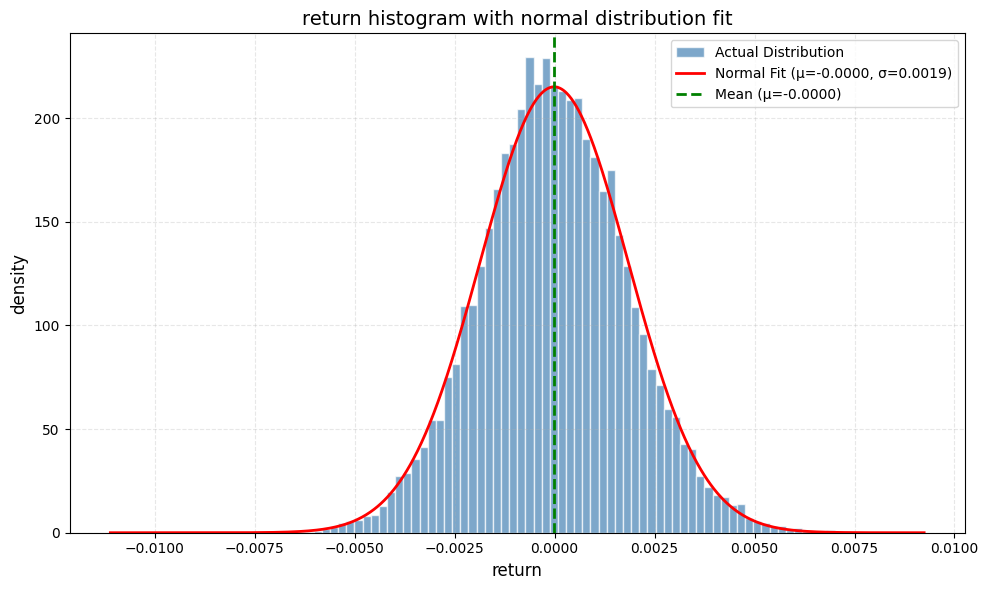

In [41]:
import numpy as np
from scipy import stats
# 绘制return的直方图，添加钟形曲线（正态分布拟合）
data = bars['return'].dropna()
plt.figure(figsize=(10, 6))

# 绘制直方图（密度归一化）
n, bins, patches = plt.hist(data, bins=100, density=True, alpha=0.7, 
                            color='steelblue', edgecolor='white', label='Actual Distribution')

# 计算正态分布拟合参数
mu, sigma = stats.norm.fit(data)
x = np.linspace(data.min(), data.max(), 1000)
pdf = stats.norm.pdf(x, mu, sigma)

# 绘制钟形曲线
plt.plot(x, pdf, 'r-', linewidth=2, label=f'Normal Fit (μ={mu:.4f}, σ={sigma:.4f})')

# 绘制均值竖线
plt.axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Mean (μ={mu:.4f})')

plt.xlabel('return', fontsize=12)
plt.ylabel('density', fontsize=12)
plt.title('return histogram with normal distribution fit', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

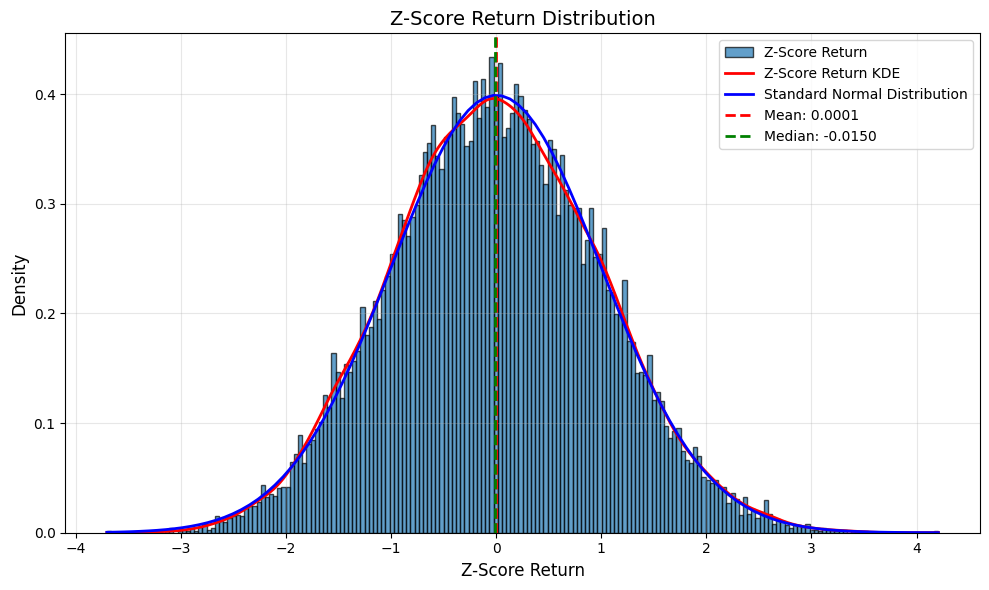

In [42]:
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde
plt.figure(figsize=(10, 6))

# 绘制直方图（使用密度而非频数，以便与概率密度函数对比）
n, bins, patches = plt.hist(bars['zscore_return'], bins=200, edgecolor='black', alpha=0.7, density=True, label='Z-Score Return')

# 过滤掉inf和NaN值用于KDE计算
clean_data = bars['zscore_return'].replace([np.inf, -np.inf], np.nan).dropna()

# 计算直方图轮廓线（使用KDE）
kde = gaussian_kde(clean_data)
x_kde = np.linspace(clean_data.min(), clean_data.max(), 1000)
plt.plot(x_kde, kde(x_kde), 'r-', linewidth=2, label='Z-Score Return KDE')

# 生成标准正态分布曲线
x = np.linspace(clean_data.min(), clean_data.max(), 100)
normal_dist = stats.norm.pdf(x, 0, 1)

# 叠加标准正态分布曲线
plt.plot(x, normal_dist, 'b-', linewidth=2, label='Standard Normal Distribution')

plt.title('Z-Score Return Distribution', fontsize=14)
plt.xlabel('Z-Score Return', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(clean_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {clean_data.mean():.4f}')
plt.axvline(clean_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {clean_data.median():.4f}')
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
bars.tail()

,open,high,low,close,volume,start_time,end_time,return,return_mean,return_std,zscore_return,log_return
18796,0.14649,0.14657,0.14625,0.14625,10000000,2025-11-30 23:57:03.141,2025-11-30 23:58:33.377,-0.001706,-0.000276,0.001055,-1.355620,-0.001708
18798,0.14624,0.14624,0.14589,0.14589,10000000,2025-11-30 23:58:33.389,2025-11-30 23:58:35.729,-0.002462,-0.000388,0.001102,-1.882038,-0.002465
18799,0.14588,0.14598,0.14580,0.14594,10000000,2025-11-30 23:58:35.729,2025-11-30 23:58:39.055,0.000343,-0.000347,0.001106,0.623816,0.000343
18800,0.14593,0.14602,0.14585,0.14585,10000000,2025-11-30 23:58:39.055,2025-11-30 23:59:05.752,-0.000617,-0.000277,0.001013,-0.335077,-0.000617
18801,0.14584,0.14600,0.14577,0.14598,10000000,2025-11-30 23:59:05.763,2025-11-30 23:59:38.441,0.000891,-0.000211,0.001023,1.077529,0.000891


In [44]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 取最近plot_count条数据
plot_count = 1000
bars_tail = bars.tail(plot_count)

# 涨跌颜色（阳线红，阴线绿）
colors = bars_tail.apply(lambda row: '#e74c3c' if row['close'] >= row['open'] else '#27ae60', axis=1)

# 创建子图
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.08,
                    subplot_titles=('Close Price', 'Z-Score Return'),
                    row_heights=[0.7, 0.3])

# ---------------------
# 子图 1：收盘价 → 散点图（你要的！）
# ---------------------
fig.add_trace(go.Scatter(
    x=bars_tail['start_time'],
    y=bars_tail['close'],
    mode='markers',        # 散点！
    marker=dict(
        color=colors,
        size=7,
        opacity=0.8
    ),
    name='Close Price'
), row=1, col=1)

# ---------------------
# 子图 2：Z-Score → 线图（你要的！）
# ---------------------
fig.add_trace(go.Scatter(
    x=bars_tail['start_time'],
    y=bars_tail['zscore_return'],
    mode='markers',          # 线！
        marker=dict(
        color=colors,
        size=7,
        opacity=0.8
    ),
    name='Z-Score Return'
), row=2, col=1)

# Z-Score 参考线
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)
fig.add_hline(y=2, line_dash="dash", line_color="green", row=2, col=1)
fig.add_hline(y=-2, line_dash="dash", line_color="red", row=2, col=1)

# 布局
fig.update_layout(
    title_text='Price (Scatter) & Z-Score (Line)',
    title_x=0.5,
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='white',
    hovermode='x unified',
    showlegend=True
)

fig.update_yaxes(title_text='Close Price', row=1, col=1)
fig.update_yaxes(title_text='Z-Score', row=2, col=1)
fig.update_xaxes(title_text='Time', row=2, col=1)

fig.show()

## 以下是示例，可能需要求zscore_return的累计和
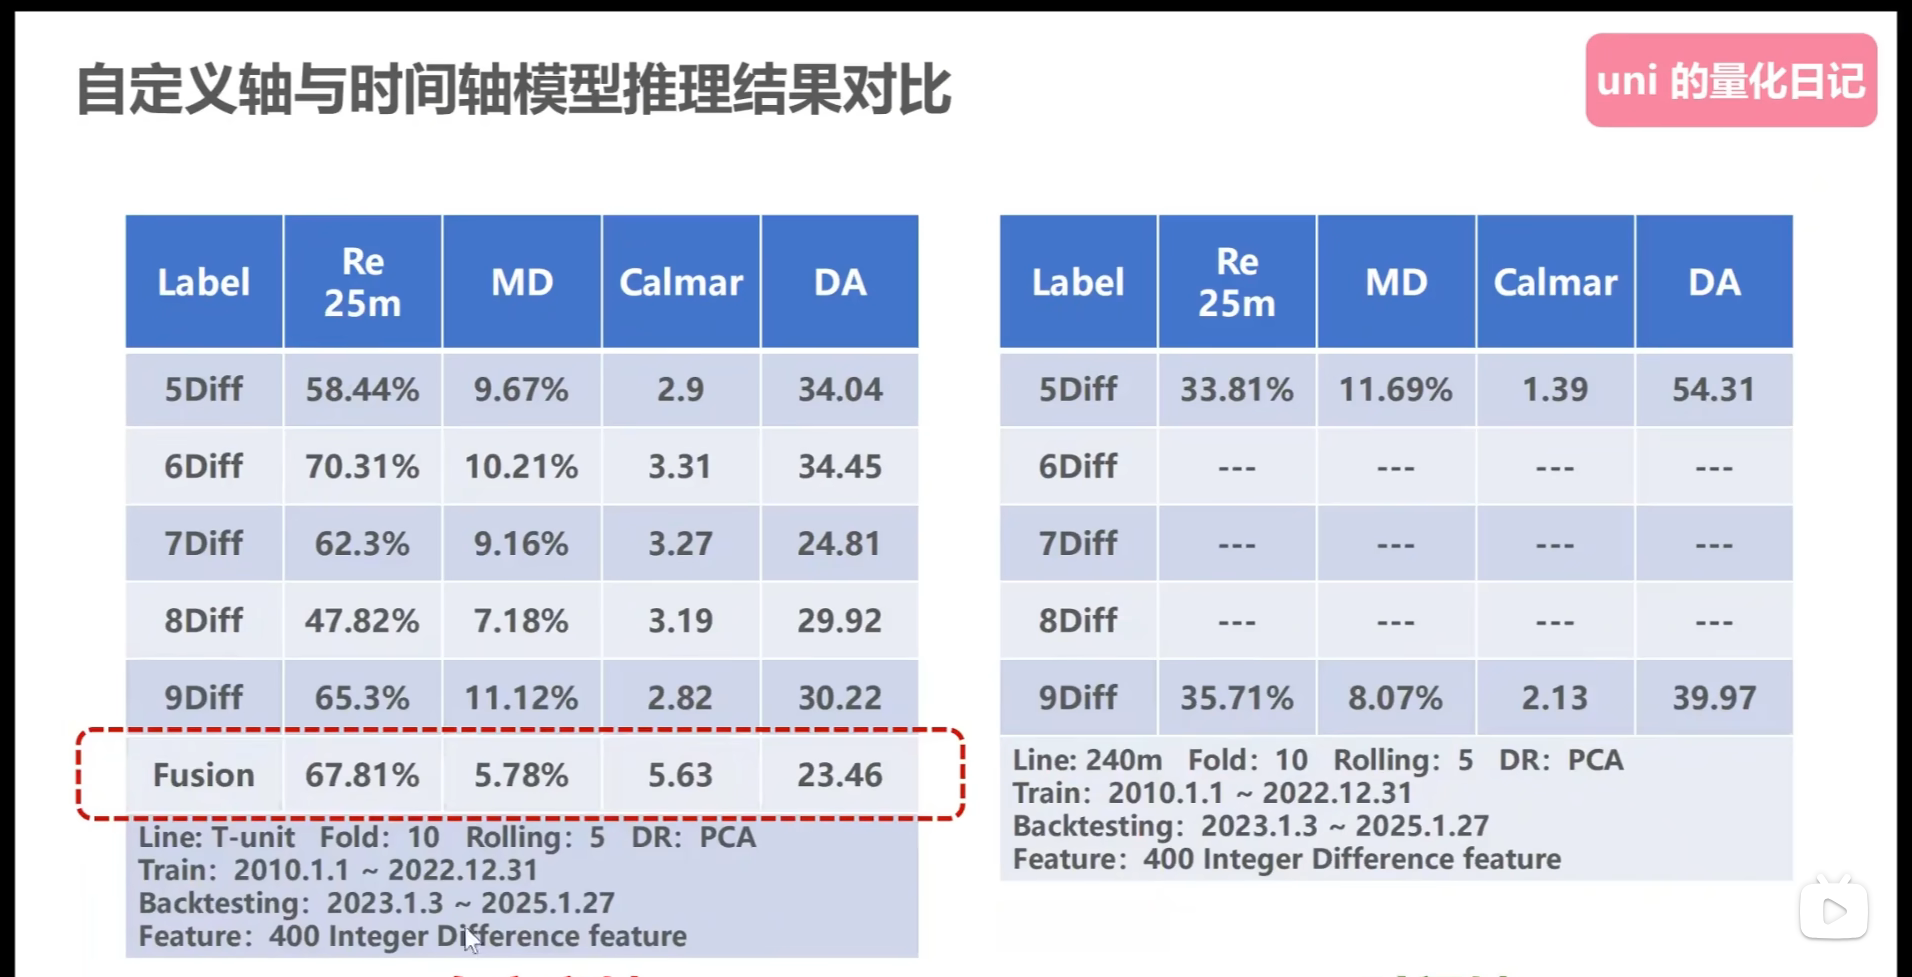

In [45]:
bars.head()

,open,high,low,close,volume,start_time,end_time,return,return_mean,return_std,zscore_return,log_return
30,0.18681,0.18696,0.18652,0.18652,10000000,2025-11-01 03:06:48.454,2025-11-01 03:11:16.861,-0.001606,0.000073,0.001455,-1.153339,-0.001607
31,0.18651,0.18683,0.18649,0.18679,10000000,2025-11-01 03:11:16.861,2025-11-01 03:18:30.767,0.001448,0.000105,0.001475,0.910306,0.001447
32,0.18679,0.18706,0.18667,0.18681,10000000,2025-11-01 03:18:33.600,2025-11-01 03:21:40.718,0.000107,0.000164,0.001437,-0.039469,0.000107
33,0.18682,0.18699,0.18672,0.18682,10000000,2025-11-01 03:21:40.775,2025-11-01 03:25:49.367,0.000054,0.000142,0.001433,-0.061901,0.000054
34,0.18682,0.18684,0.18665,0.18678,10000000,2025-11-01 03:25:49.559,2025-11-01 03:32:20.900,-0.000214,0.000187,0.001399,-0.286781,-0.000214


In [46]:
print(bars['zscore_return'].max())
print(bars['zscore_return'].min())
print(bars['zscore_return'].mean())
print(len(bars))
print(len(agg_df))
print((bars['zscore_return']>2).sum())
print((bars['zscore_return']<-2).sum())


4.20836406594943
-3.7053612357960453
0.000102831788966496
18765
9975383
430
343


In [47]:
import pandas as pd
import numpy as np
# 回测一下策略，当bars['zscore_return']>2时做空，当bars['zscore_return']<-2时做多，当回到0时平仓，统计最后的收益率

def backtest_strategy(bars, initial_capital=100000):
    """
    回测均值回归策略
    当zscore_return > 2时做空，<-2时做多，回到0时平仓
    """
    position = 0  # 0: 无仓位, 1: 做多, -1: 做空
    entry_price = 0
    capital = initial_capital
    trades = []
    
    for i in range(len(bars)):
        zscore = bars['zscore_return'].iloc[i]
        price = bars['close'].iloc[i] if 'close' in bars.columns else bars['price'].iloc[i]
        
        # 开多仓条件：无仓位且zscore < -2
        if position == 0 and zscore < -2:
            position = 1
            entry_price = price
            trades.append({'type': 'open_long', 'price': price, 'index': i})
        
        # 开空仓条件：无仓位且zscore > 2
        elif position == 0 and zscore > 2:
            position = -1
            entry_price = price
            trades.append({'type': 'open_short', 'price': price, 'index': i})
        
        # 平多仓条件：持有多仓且zscore回到0附近（穿过0或接近0）
        elif position == 1 and zscore >= 0:
            # 计算收益
            pnl = (price - entry_price) / entry_price * capital
            capital += pnl
            trades.append({
                'type': 'close_long', 
                'price': price, 
                'pnl': pnl,
                'return': (price - entry_price) / entry_price,
                'index': i
            })
            position = 0
            entry_price = 0
        
        # 平空仓条件：持有空仓且zscore回到0附近（穿过0或接近0）
        elif position == -1 and zscore <= 0:
            # 计算收益（做空收益 = (入场价 - 出场价) / 入场价）
            pnl = (entry_price - price) / entry_price * capital
            capital += pnl
            trades.append({
                'type': 'close_short', 
                'price': price, 
                'pnl': pnl,
                'return': (entry_price - price) / entry_price,
                'index': i
            })
            position = 0
            entry_price = 0
    
    # 如果最后还有持仓，强制平仓
    if position != 0:
        price = bars['close'].iloc[-1] if 'close' in bars.columns else bars['price'].iloc[-1]
        if position == 1:
            pnl = (price - entry_price) / entry_price * capital
            trades.append({
                'type': 'close_long_final', 
                'price': price, 
                'pnl': pnl,
                'return': (price - entry_price) / entry_price,
                'index': len(bars) - 1
            })
        else:
            pnl = (entry_price - price) / entry_price * capital
            trades.append({
                'type': 'close_short_final', 
                'price': price, 
                'pnl': pnl,
                'return': (entry_price - price) / entry_price,
                'index': len(bars) - 1
            })
        capital += pnl
    
    # 计算回测结果
    total_return = (capital - initial_capital) / initial_capital * 100
    num_trades = len([t for t in trades if 'open' in t['type']])
    
    # 统计盈利和亏损交易
    closed_trades = [t for t in trades if 'close' in t['type']]
    winning_trades = [t for t in closed_trades if t.get('pnl', 0) > 0]
    losing_trades = [t for t in closed_trades if t.get('pnl', 0) <= 0]
    
    result = {
        'initial_capital': initial_capital,
        'final_capital': capital,
        'total_return_pct': total_return,
        'total_trades': num_trades,
        'winning_trades': len(winning_trades),
        'losing_trades': len(losing_trades),
        'win_rate': len(winning_trades) / len(closed_trades) * 100 if closed_trades else 0,
        'trades': trades
    }
    
    print(f"初始资金: {initial_capital:,.2f}")
    print(f"最终资金: {capital:,.2f}")
    print(f"总收益率: {total_return:.2f}%")
    print(f"总交易次数: {num_trades}")
    print(f"盈利次数: {len(winning_trades)}")
    print(f"亏损次数: {len(losing_trades)}")
    print(f"胜率: {result['win_rate']:.2f}%")
    
    return result

# 执行回测
result = backtest_strategy(bars)
"""
初始资金: 100,000.00
最终资金: 104,680.79
总收益率: 4.68%
总交易次数: 699
盈利次数: 432
亏损次数: 267
胜率: 61.80%

初始资金: 100,000.00
最终资金: 106,314.85
总收益率: 6.31%
总交易次数: 477
盈利次数: 307
亏损次数: 170
胜率: 64.36%

初始资金: 100,000.00
最终资金: 92,580.62
总收益率: -7.42%
总交易次数: 607
盈利次数: 365
亏损次数: 242
胜率: 60.13%

初始资金: 100,000.00
最终资金: 100,879.10
总收益率: 0.88%
总交易次数: 723
盈利次数: 442
亏损次数: 281
胜率: 61.13%

初始资金: 100,000.00
最终资金: 105,897.99
总收益率: 5.90%
总交易次数: 758
盈利次数: 460
亏损次数: 298
胜率: 60.69%
"""

初始资金: 100,000.00
最终资金: 104,742.71
总收益率: 4.74%
总交易次数: 699
盈利次数: 432
亏损次数: 267
胜率: 61.80%


'\n初始资金: 100,000.00\n最终资金: 104,680.79\n总收益率: 4.68%\n总交易次数: 699\n盈利次数: 432\n亏损次数: 267\n胜率: 61.80%\n\n初始资金: 100,000.00\n最终资金: 106,314.85\n总收益率: 6.31%\n总交易次数: 477\n盈利次数: 307\n亏损次数: 170\n胜率: 64.36%\n\n初始资金: 100,000.00\n最终资金: 92,580.62\n总收益率: -7.42%\n总交易次数: 607\n盈利次数: 365\n亏损次数: 242\n胜率: 60.13%\n\n初始资金: 100,000.00\n最终资金: 100,879.10\n总收益率: 0.88%\n总交易次数: 723\n盈利次数: 442\n亏损次数: 281\n胜率: 61.13%\n\n初始资金: 100,000.00\n最终资金: 105,897.99\n总收益率: 5.90%\n总交易次数: 758\n盈利次数: 460\n亏损次数: 298\n胜率: 60.69%\n'

In [48]:
import pandas as pd
import numpy as np

def backtest_strategy_final_v2(bars, initial_capital=100000):
    """
    终极优化版：
    1. 增加手续费模拟 (0.1%)
    2. 提高入场阈值 (Z > 2.3) 过滤伪信号
    3. 延迟平仓逻辑，提升单笔盈亏比
    """
    # --- 参数设定 ---
    z_entry = 2.3             # 提高入场门槛
    z_exit = 0.5              # 允许价格穿过0轴，博取更多回归利润
    stop_loss_pct = 0.03      # 止损稍微放宽，避免被随机噪音扫出
    fee_rate = 0.001          # 模拟单边 0.1% 手续费 (佣金+滑点)
    ma_period = 200
    
    df = bars.copy()
    price_col = 'close' if 'close' in df.columns else 'price'
    df['ma'] = df[price_col].rolling(window=ma_period).mean()
    
    capital = initial_capital
    side, entry_price = 0, 0
    trades = []
    equity_curve = [initial_capital] * ma_period
    
    prices = df[price_col].values
    zscores = df['zscore_return'].values
    mas = df['ma'].values

    # --- 回测循环 ---
    for i in range(ma_period, len(df)):
        cur_p, cur_z, cur_ma = prices[i], zscores[i], mas[i]
        
        if side != 0:
            # 计算当前变动百分比
            pct_change = (cur_p - entry_price) / entry_price if side == 1 else (entry_price - cur_p) / entry_price
            
            # 平仓逻辑：1.硬性止损 2.延迟回归平仓
            is_stop_loss = pct_change <= -stop_loss_pct
            is_take_profit = (side == 1 and cur_z >= z_exit) or (side == -1 and cur_z <= -z_exit)
            
            if is_stop_loss or is_take_profit:
                # 扣除出场手续费
                exit_fee = capital * fee_rate
                capital = capital * (1 + pct_change) - exit_fee
                trades.append({
                    'ret': pct_change - fee_rate*2, # 近似净收益
                    'type': 'SL' if is_stop_loss else 'TP'
                })
                side, entry_price = 0, 0
        else:
            # 入场逻辑：增加趋势过滤和高Z阈值
            if cur_z < -z_entry and cur_p > cur_ma:
                # 扣除进场手续费
                capital -= capital * fee_rate
                side, entry_price = 1, cur_p
            elif cur_z > z_entry and cur_p < cur_ma:
                capital -= capital * fee_rate
                side, entry_price = -1, cur_p
        
        equity_curve.append(capital)

    # --- 指标计算 ---
    equity = pd.Series(equity_curve)
    daily_rets = equity.pct_change().dropna()
    
    total_return = (capital - initial_capital) / initial_capital
    # 计算年化：根据数据实际天数计算
    days = len(df)
    ann_return = (1 + total_return) ** (252 / days) - 1 if total_return > -1 else -1
    
    # 夏普比率 (假设无风险利率 0.01)
    rf = 0.01
    sharpe = (daily_rets.mean() * 252 - rf) / (daily_rets.std() * np.sqrt(252)) if daily_rets.std() > 0 else 0
    
    # 最大回撤
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    
    # 交易统计
    perf = pd.DataFrame(trades)
    win_rate = (perf['ret'] > 0).mean() if not perf.empty else 0
    profit_factor = abs(perf[perf['ret']>0]['ret'].sum() / perf[perf['ret']<0]['ret'].sum()) if len(perf[perf['ret']<0]) > 0 else 0

    # --- 输出报告 ---
    print("="*40)
    print(f"{'终极优化策略报告':^34}")
    print("="*40)
    print(f"【财务表现】")
    print(f"最终资金:      {capital:,.2f} (已扣费)")
    print(f"年化收益率:    {ann_return:.2%}")
    print(f"最大回撤:      {max_dd:.2%}")
    print("-" * 40)
    print(f"【风险质量】")
    print(f"夏普比率 (SR):  {sharpe:.2f}")
    print(f"盈亏比:        {profit_factor:.2f}")
    print(f"卡玛比率:      {abs(ann_return/max_dd) if max_dd !=0 else 0:.2f}")
    print("-" * 40)
    print(f"【交易特征】")
    print(f"总交易次数:    {len(perf)}")
    print(f"平均单笔净盈亏: {perf['ret'].mean():.2%}")
    print(f"胜率:          {win_rate:.2%}")
    print("="*40)
    
    return perf, equity

# 运行
final_perf, final_equity = backtest_strategy_final_v2(bars)
"""
--- 进阶回测报告 ---
最终资金: 111,114.89
总收益率: 11.11%
交易次数: 380
平均单笔收益: 0.0281%
最高单笔盈利: 1.1110%
最大单笔亏损: -1.2192%
胜率: 65.53%


--- 进阶回测报告 ---
最终资金: 102,181.94
总收益率: 2.18%
交易次数: 243
平均单笔收益: 0.0092%
最高单笔盈利: 0.5518%
最大单笔亏损: -1.2697%
胜率: 67.08%

--- 进阶回测报告 ---
最终资金: 99,019.58
总收益率: -0.98%
交易次数: 348
平均单笔收益: -0.0024%
最高单笔盈利: 1.1864%
最大单笔亏损: -1.5625%
胜率: 62.07%

--- 进阶回测报告 ---
最终资金: 107,277.86
总收益率: 7.28%
交易次数: 400
平均单笔收益: 0.0180%
最高单笔盈利: 0.8850%
最大单笔亏损: -1.4651%
胜率: 65.50%

--- 进阶回测报告 ---
最终资金: 106,137.11
总收益率: 6.14%
交易次数: 411
平均单笔收益: 0.0148%
最高单笔盈利: 0.9863%
最大单笔亏损: -0.9885%
胜率: 62.04%
"""

             终极优化策略报告             
【财务表现】
最终资金:      76,549.04 (已扣费)
年化收益率:    -0.36%
最大回撤:      -23.48%
----------------------------------------
【风险质量】
夏普比率 (SR):  -2.51
盈亏比:        0.20
卡玛比率:      0.02
----------------------------------------
【交易特征】
总交易次数:    163
平均单笔净盈亏: -0.16%
胜率:          30.06%


'\n--- 进阶回测报告 ---\n最终资金: 111,114.89\n总收益率: 11.11%\n交易次数: 380\n平均单笔收益: 0.0281%\n最高单笔盈利: 1.1110%\n最大单笔亏损: -1.2192%\n胜率: 65.53%\n\n\n--- 进阶回测报告 ---\n最终资金: 102,181.94\n总收益率: 2.18%\n交易次数: 243\n平均单笔收益: 0.0092%\n最高单笔盈利: 0.5518%\n最大单笔亏损: -1.2697%\n胜率: 67.08%\n\n--- 进阶回测报告 ---\n最终资金: 99,019.58\n总收益率: -0.98%\n交易次数: 348\n平均单笔收益: -0.0024%\n最高单笔盈利: 1.1864%\n最大单笔亏损: -1.5625%\n胜率: 62.07%\n\n--- 进阶回测报告 ---\n最终资金: 107,277.86\n总收益率: 7.28%\n交易次数: 400\n平均单笔收益: 0.0180%\n最高单笔盈利: 0.8850%\n最大单笔亏损: -1.4651%\n胜率: 65.50%\n\n--- 进阶回测报告 ---\n最终资金: 106,137.11\n总收益率: 6.14%\n交易次数: 411\n平均单笔收益: 0.0148%\n最高单笔盈利: 0.9863%\n最大单笔亏损: -0.9885%\n胜率: 62.04%\n'

In [49]:
bars.head()

,open,high,low,close,volume,start_time,end_time,return,return_mean,return_std,zscore_return,log_return
30,0.18681,0.18696,0.18652,0.18652,10000000,2025-11-01 03:06:48.454,2025-11-01 03:11:16.861,-0.001606,0.000073,0.001455,-1.153339,-0.001607
31,0.18651,0.18683,0.18649,0.18679,10000000,2025-11-01 03:11:16.861,2025-11-01 03:18:30.767,0.001448,0.000105,0.001475,0.910306,0.001447
32,0.18679,0.18706,0.18667,0.18681,10000000,2025-11-01 03:18:33.600,2025-11-01 03:21:40.718,0.000107,0.000164,0.001437,-0.039469,0.000107
33,0.18682,0.18699,0.18672,0.18682,10000000,2025-11-01 03:21:40.775,2025-11-01 03:25:49.367,0.000054,0.000142,0.001433,-0.061901,0.000054
34,0.18682,0.18684,0.18665,0.18678,10000000,2025-11-01 03:25:49.559,2025-11-01 03:32:20.900,-0.000214,0.000187,0.001399,-0.286781,-0.000214


In [50]:
bars.columns

Index(['open', 'high', 'low', 'close', 'volume', 'start_time', 'end_time',
       'return', 'return_mean', 'return_std', 'zscore_return', 'log_return'],
      dtype='object')

In [51]:
len(bars)

18765

In [52]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

df = bars.copy()
df = df.sort_values("start_time").reset_index(drop=True)

# ======================
# 1. 数据准备
# ======================

df = df.dropna().copy()

# ======================
# 2. HMM（使用更多特征和3个状态）
# ======================

# 基础收益率
df["ret_1"] = df["return"]

# 波动率特征（多时间尺度）
df["vol_5"] = df["return"].rolling(5).std()
df["vol_10"] = df["return"].rolling(10).std()
df["vol_20"] = df["return"].rolling(20).std()

# 动量特征（多时间尺度）
df["momentum_5"] = df["close"] / df["close"].shift(5) - 1
df["momentum_10"] = df["close"] / df["close"].shift(10) - 1
df["momentum_20"] = df["close"] / df["close"].shift(20) - 1

# 趋势特征
df["sma_ratio"] = df["close"].rolling(10).mean() / df["close"].rolling(30).mean() - 1

# 价格位置特征
df["high_low_ratio"] = (df["close"] - df["low"].rolling(20).min()) / (df["high"].rolling(20).max() - df["low"].rolling(20).min() + 1e-10)

df = df.dropna()

# 选择特征
feature_cols = ["ret_1", "vol_5", "vol_10", "vol_20", "momentum_5", "momentum_10", "momentum_20", "sma_ratio", "high_low_ratio"]
X = df[feature_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# 使用3个状态：上涨、震荡、下跌
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=2000,
    random_state=42,
    tol=1e-4
)

model.fit(X)
df["state"] = model.predict(X)

# 根据状态统计重新标记状态，使标签更有意义
state_stats = df.groupby("state")[["ret_1", "vol_10", "momentum_10"]].mean()
print("各状态统计特征：")
print(state_stats)

# 根据收益率均值排序状态：0=下跌，1=震荡，2=上涨
state_order = state_stats["ret_1"].argsort().values
state_map = {old: new for new, old in enumerate(state_order)}
df["state"] = df["state"].map(state_map)

# ======================
# 3. 检查分布
# ======================

print(df[feature_cols].describe())

# 各状态分布
print("\n各状态样本数：")
print(df["state"].value_counts().sort_index())

# ======================
# 4. 可视化
# ======================

# 设置显示数据量
n = 6000  # 可修改此变量来控制显示的数据点数量

# 取最近n条数据
df_plot = df.tail(n).copy()

fig = go.Figure()

# 为每个状态添加散点（上涨=绿色，震荡=黄色，下跌=红色）
colors = ['red', 'orange', 'green']
state_names = ['Down (下跌)', 'Neutral (震荡)', 'Up (上涨)']
for s in range(3):
    mask = df_plot["state"] == s
    fig.add_trace(go.Scatter(
        x=df_plot["start_time"][mask],
        y=df_plot["close"][mask],
        mode='markers',
        name=f"State {s}: {state_names[s]}",
        marker=dict(size=5, color=colors[s])
    ))

# 添加收盘价连线作为背景
fig.add_trace(go.Scatter(
    x=df_plot["start_time"],
    y=df_plot["close"],
    mode='lines',
    name='Close Price',
    line=dict(color='gray', width=1),
    opacity=0.3
))

fig.update_layout(
    title=f"HMM States Visualization (Last {n} points, 3 States)",
    xaxis_title="Time",
    yaxis_title="Close Price",
    width=1400,
    height=700,
    showlegend=True
)

fig.show()


各状态统计特征：
          ret_1    vol_10  momentum_10
state                                 
0     -0.000443  0.001620    -0.005381
1      0.000111  0.001532     0.001242
2      0.000284  0.002164     0.003653
              ret_1         vol_5        vol_10        vol_20    momentum_5  \
count  18736.000000  18736.000000  18736.000000  18736.000000  18736.000000   
mean      -0.000011      0.001705      0.001768      0.001798     -0.000056   
std        0.001856      0.000721      0.000552      0.000448      0.004196   
min       -0.011110      0.000123      0.000272      0.000623     -0.023551   
25%       -0.001230      0.001186      0.001377      0.001483     -0.003002   
50%       -0.000055      0.001623      0.001714      0.001769     -0.000249   
75%        0.001207      0.002126      0.002108      0.002075      0.002710   
max        0.009241      0.007481      0.005997      0.005261      0.024647   

        momentum_10   momentum_20     sma_ratio  high_low_ratio  
count  18736.00000

In [53]:
print(df.groupby("state")[["return"]].agg(["mean", "std"]))


         return          
           mean       std
state                    
0     -0.000443  0.001600
1      0.000111  0.001610
2      0.000284  0.002221


In [54]:
df.tail()

,open,high,low,close,volume,start_time,end_time,return,return_mean,return_std,...,ret_1,vol_5,vol_10,vol_20,momentum_5,momentum_10,momentum_20,sma_ratio,high_low_ratio,state
18760,0.14649,0.14657,0.14625,0.14625,10000000,2025-11-30 23:57:03.141,2025-11-30 23:58:33.377,-0.001706,-0.000276,0.001055,...,-0.001706,0.001217,0.001073,0.001086,-0.003950,-0.002387,-0.003407,-0.001078,0.000000,0
18761,0.14624,0.14624,0.14589,0.14589,10000000,2025-11-30 23:58:33.389,2025-11-30 23:58:35.729,-0.002462,-0.000388,0.001102,...,-0.002462,0.000759,0.001250,0.001195,-0.007551,-0.005250,-0.006063,-0.001213,0.000000,0
18762,0.14588,0.14598,0.14580,0.14594,10000000,2025-11-30 23:58:35.729,2025-11-30 23:58:39.055,0.000343,-0.000347,0.001106,...,0.000343,0.001095,0.001267,0.001136,-0.005452,-0.004977,-0.007143,-0.001333,0.110236,0
18763,0.14593,0.14602,0.14585,0.14585,10000000,2025-11-30 23:58:39.055,2025-11-30 23:59:05.752,-0.000617,-0.000277,0.001013,...,-0.000617,0.001110,0.001100,0.001129,-0.004844,-0.006877,-0.006810,-0.001654,0.039370,0
18764,0.14584,0.14600,0.14577,0.14598,10000000,2025-11-30 23:59:05.763,2025-11-30 23:59:38.441,0.000891,-0.000211,0.001023,...,0.000891,0.001391,0.001200,0.001155,-0.003549,-0.005857,-0.005111,-0.001993,0.161538,0


In [55]:
import talib as ta
#给bars添加一些指标
bars['ma_50'] = ta.SMA(bars['close'], 50)
bars['ma_200'] = ta.SMA(bars['close'], 200)
bars['rsi'] = ta.RSI(bars['close'], 14)
bars['ema_20'] = ta.EMA(bars['close'], 20)
bars['macd'], bars['macd_signal'], bars['macd_hist'] = ta.MACD(bars['close'], fastperiod=12, slowperiod=26, signalperiod=9)
bars['bb_upper'], bars['bb_middle'], bars['bb_lower'] = ta.BBANDS(bars['close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
bars['atr'] = ta.ATR(bars['high'], bars['low'], bars['close'], timeperiod=14)
bars['stoch_k'], bars['stoch_d'] = ta.STOCH(bars['high'], bars['low'], bars['close'], fastk_period=14, slowk_period=3, slowd_period=3)


In [56]:
bars.columns

Index(['open', 'high', 'low', 'close', 'volume', 'start_time', 'end_time',
       'return', 'return_mean', 'return_std', 'zscore_return', 'log_return',
       'ma_50', 'ma_200', 'rsi', 'ema_20', 'macd', 'macd_signal', 'macd_hist',
       'bb_upper', 'bb_middle', 'bb_lower', 'atr', 'stoch_k', 'stoch_d'],
      dtype='object')

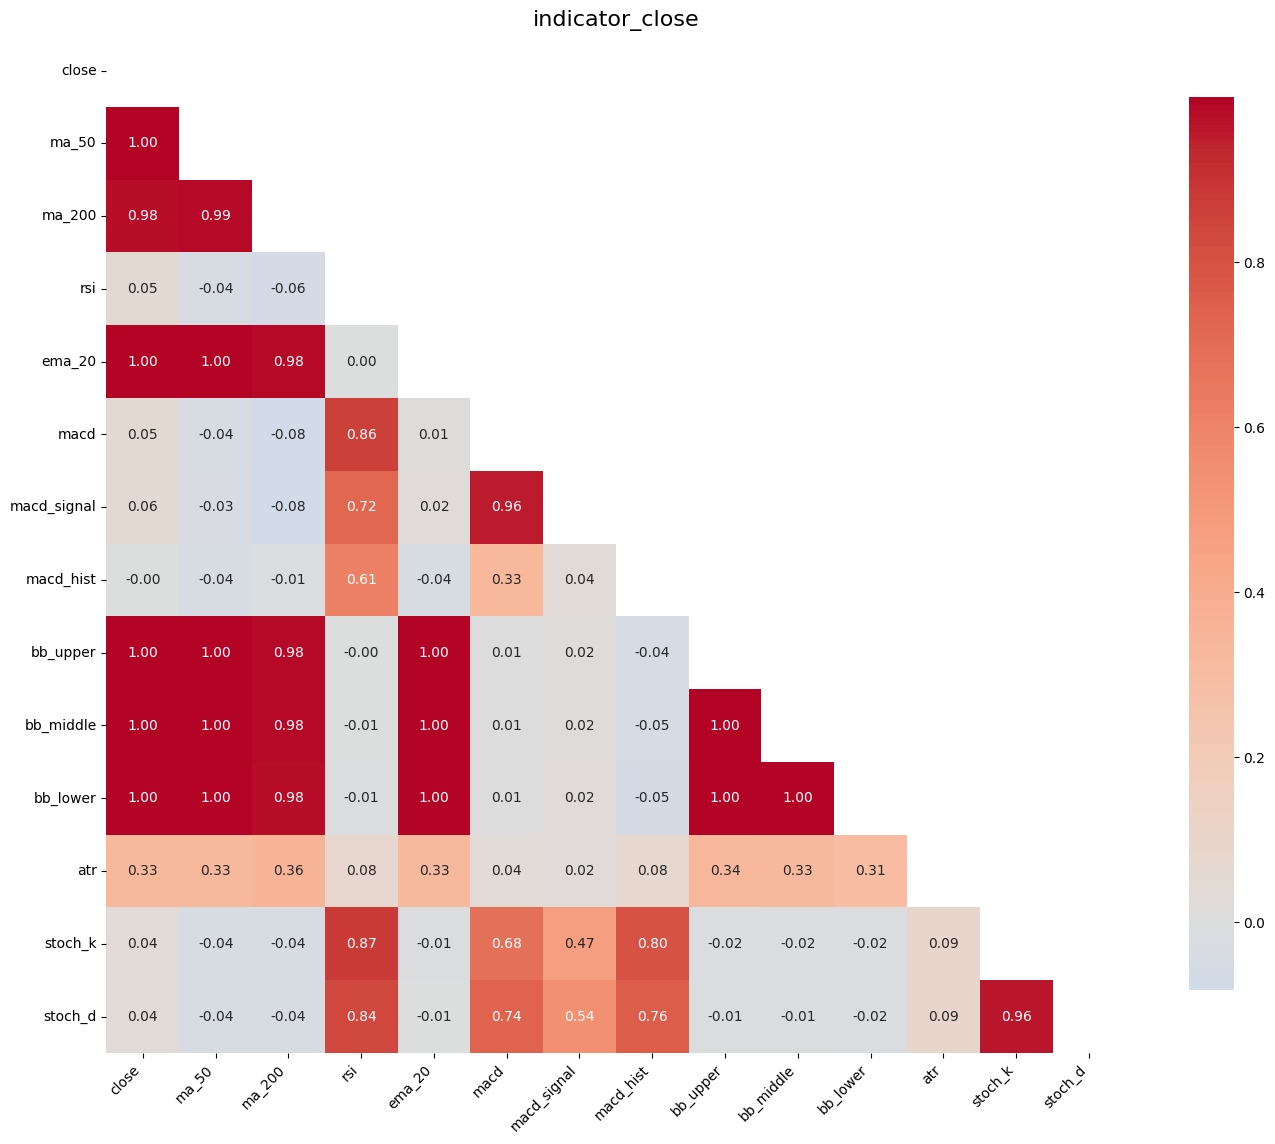

<Figure size 640x480 with 0 Axes>

In [57]:

# 提取指定的指标数据
indicators = ['close', 'ma_50', 'ma_200', 'rsi', 'ema_20', 'macd', 'macd_signal', 'macd_hist',
              'bb_upper', 'bb_middle', 'bb_lower', 'atr', 'stoch_k', 'stoch_d']
indicator_data = bars[indicators]

# 计算相关系数矩阵
corr_matrix = indicator_data.corr()

# 创建掩码，隐藏右半边（包括对角线）
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

# 绘制热力图（只显示左半边）
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('indicator_close', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('indicator_close.png')
